In [1]:
from graph_transformer_long_range_niches.tl.wandb import load_and_log
from graph_transformer_long_range_niches.tl.load_config import Config
from graph_transformer_long_range_niches._paths import CFG_FILES, HE22_HUMAN_LUNG_DATA_PATH
from graph_transformer_long_range_niches.model.gnn_transformer import LitGNNTransformer
from graph_transformer_long_range_niches.tl.utils import pad_batch
from graph_transformer_long_range_niches.tl.evaluation import eval_gnntransformer, extract_attention
from graph_transformer_long_range_niches.pl.color_map import CustomColormap
from graph_transformer_long_range_niches.pp.geome_utils import prepare_geome_dataset
from graph_transformer_long_range_niches.config import load_config
from graph_transformer_long_range_niches.pl.attention_matrix import plot_attention_sender_receiver

import warnings
warnings.filterwarnings("ignore")

from torch_geometric.loader import DataLoader

from pathlib import Path
import wandb
import torch
import os

## plotting
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

import scanpy as sc
import squidpy as sq

# Utility functions

In [2]:
def read(data_dir, split):
    """ Read PyG data from artifact folder
    """
    filename = split + ".pt"
    pyg_data = torch.load(os.path.join(data_dir, filename))
    return pyg_data # list with PyG Data objects

In [3]:
# subset adata to validation set
def subset_adata(pyg_datas, adata):
    """
    Subset adata according to the obs_names in a pyg object
    """
    sub_obs_names = []
    sub_adata = []
    for i, pyg in enumerate(pyg_datas):
        sub_obs_names.append(pyg.obs_names.numpy().astype(int).astype(str).tolist())
        sub_adata.append(adata[adata.obs_names.isin(sub_obs_names[i])])
    return sub_adata

# Global parameters

In [4]:
plt.rcParams['figure.figsize'] = (30, 20)

In [5]:
artifact_dir = '/home/icb/francesca.drummer/1-Projects/GT-long-range-niches/docs/notebooks/artifacts'
cfg_path = Path(CFG_FILES, 'pancreas_gnntrans_graph_condition.yaml')

In [6]:
# load config 
cfg = load_config(cfg_path)

## Load data

In [7]:
data_name = f"{cfg.dataset.name}_{cfg.dataset.prediction_obs}_{cfg.dataset.library_key}"
model_name = f"{data_name}_{cfg.model.model_type}"
model_path = f'{artifact_dir}/{model_name}_model/{model_name}.ckpt'
#model_path = f'{artifact_dir}/{model_name}_model:v0/pancreas_model.ckpt'
checkpoint = torch.load(model_path)
cfg = checkpoint['hyper_parameters']['cfg']
model = LitGNNTransformer(cfg)
model.load_state_dict(checkpoint['state_dict'])

<All keys matched successfully>

In [8]:
data_dir = f"{artifact_dir}/{model_name}_model" #TODO: adjust to downloaded dataset
pyg_data_val = read(data_dir, 'validation')
pyg_data_val[:3]

[Data(x=[561, 979], edge_index=[2, 340], y=[561, 2], obs_names=[561]),
 Data(x=[754, 979], edge_index=[2, 904], y=[754, 2], obs_names=[754]),
 Data(x=[685, 979], edge_index=[2, 696], y=[685, 2], obs_names=[685])]

In [9]:
adata = read(data_dir, 'adata')
adata

AnnData object with n_obs × n_vars = 108711 × 979
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.GCG', 'Max.GCG', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'condition', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_NegPrb', 'log1p_total_counts_NegPrb', 'pct_counts_NegPrb', 'n_genes', 'cell_type_coarse', 'x', 'y', 'sliding_window'
    var: 'NegPrb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'log1p', 'spatial', 'one_hot_mappings'
    obsm: 'spatial', 'spatial_fov', 'one_hot'
    layers: 'counts'

# Evaluation on validation data

In [10]:
val_adata_list = subset_adata(pyg_data_val, adata)
val_adata_list

[View of AnnData object with n_obs × n_vars = 561 × 979
     obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.GCG', 'Max.GCG', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'condition', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_NegPrb', 'log1p_total_counts_NegPrb', 'pct_counts_NegPrb', 'n_genes', 'cell_type_coarse', 'x', 'y', 'sliding_window'
     var: 'NegPrb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
     uns: 'log1p', 'spatial', 'one_hot_mappings'
     obsm: 'spatial', 'spatial_fov', 'one_hot'
     layers: 'counts',
 View of AnnData object with n_obs × n_vars = 754 × 979
    

transformer in: torch.Size([1000, 1, 128]), out: torch.Size([1001, 1, 128])
['Acinar' 'Alpha' 'Beta' 'Ductal' 'Endocrine' 'Endothelial' 'Fibroblasts'
 'Immune' 'Mast']


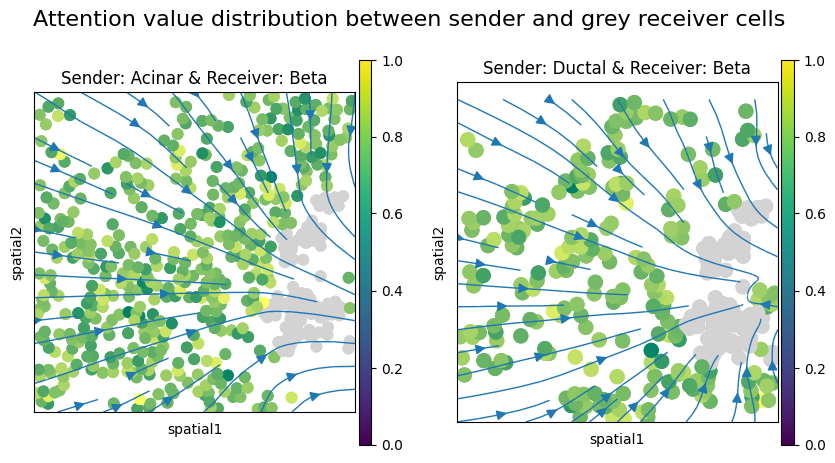

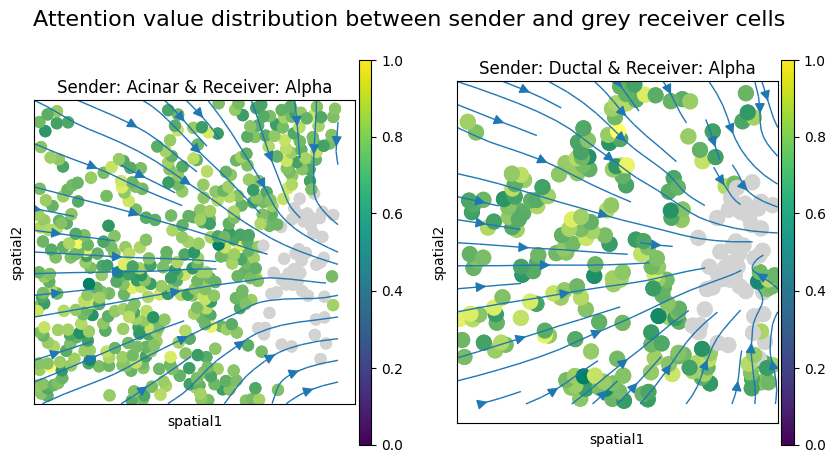

transformer in: torch.Size([654, 1, 128]), out: torch.Size([655, 1, 128])
['Acinar' 'Beta' 'Ductal' 'Endothelial' 'Fibroblasts' 'Immune' 'Mast']


ValueError: No axis named 1 for object type Series

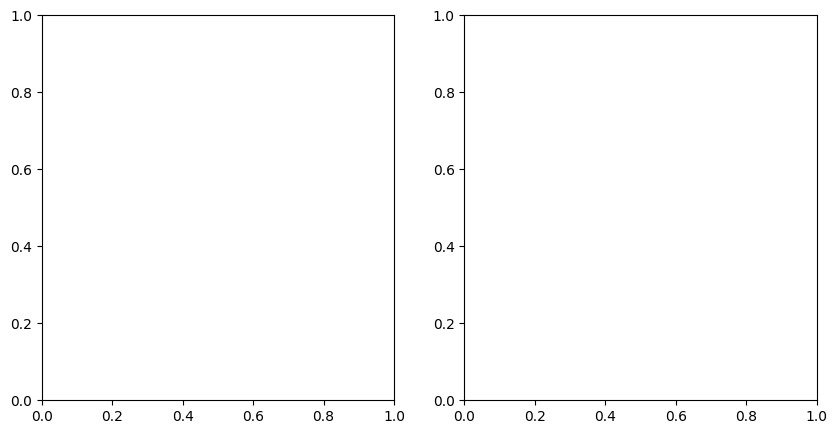

In [13]:
start, end = 11,14
eval_loader = DataLoader(pyg_data_val[start:end], 1)
for i, batch in enumerate(eval_loader):
    #transformer_in, transformer_out, src_padding_mask, index_nodes = eval_gnntransformer(model, batch)
    transformer_in, transformer_out, src_padding_mask, index_nodes = model.evaluation(model, batch)
    print(f'transformer in: {transformer_in.shape}, out: {transformer_out.shape}')
    attn_maps, attn_weights_maps = extract_attention(model.transformer_encoder, transformer_out, src_padding_mask)
    val_adata = val_adata_list[i+start]
    sub_obs_names = val_adata.obs_names[index_nodes[0]]
    str_list = [i for i in sub_obs_names]
    val_adata = val_adata[val_adata.obs_names.isin(str_list)].copy()
    val_adata.obsm["attention_matrix"] = attn_weights_maps[0].squeeze(0)[1:, 1:].numpy()
    print(np.unique(val_adata.obs['cell_type_coarse']))
    plot_attention_sender_receiver(val_adata, ['Acinar', 'Ductal'], 'Beta', cell_type_key = 'cell_type_coarse', attn_matrix_key='attention_matrix', add_streamline = True)
    plot_attention_sender_receiver(val_adata, ['Acinar', 'Ductal'], 'Alpha', cell_type_key = 'cell_type_coarse', attn_matrix_key='attention_matrix', add_streamline = True)

In [11]:
val_adata.obsm["attention_matrix"]

array([[0.0010247 , 0.00073211, 0.00105885, ..., 0.0012433 , 0.00045736,
        0.00157291],
       [0.00175753, 0.00121579, 0.00106885, ..., 0.00024027, 0.00103125,
        0.00219268],
       [0.00179151, 0.00151693, 0.00168686, ..., 0.00095858, 0.00093677,
        0.00159364],
       ...,
       [0.00189525, 0.00120982, 0.00091439, ..., 0.00169986, 0.00088919,
        0.00206696],
       [0.00033241, 0.00078371, 0.00179221, ..., 0.00085239, 0.00229367,
        0.00230432],
       [0.00056359, 0.00077514, 0.00118646, ..., 0.00150804, 0.00211164,
        0.00438018]], dtype=float32)

In [56]:
val_adata = val_adata_list[6]
val_adata.obsm["attention_matrix"] = attn_weights_maps[0].squeeze(0)[1:, 1:].numpy()
val_adata.obs['cell_type_coarse']

ValueError: Value passed for key 'attention_matrix' is of incorrect shape. Values of obsm must match dimensions ('obs',) of parent. Value had shape (808,) while it should have had (898,).

In [ ]:
plot_attention_sender_receiver(val_adata, 'Acinar', 'Endothelial', cell_type_key = 'cell_type_coarse', attn_matrix_key='attention_matrix', add_streamline = True)

## Var by distance

In [12]:
sq.tl.var_by_distance(
    adata=val_adata,
    groups="Beta",
    cluster_key="cell_type_coarse",
    library_key="sliding_window"
)

In [13]:
val_adata.obsm['design_matrix']

,cell_type_coarse,sliding_window,Beta,Beta_raw
75100,Acinar,18_1_1,0.320339,565.729617
75110,Acinar,18_1_1,0.234766,414.605837
75112,Acinar,18_1_1,0.166314,293.715849
75113,Acinar,18_1_1,0.207528,366.502387
75114,Endothelial,18_1_1,0.838376,1480.601229
...,...,...,...,...
79337,Acinar,18_1_1,0.326677,576.922872
79340,Acinar,18_1_1,1.000000,1766.035107
79343,Fibroblasts,18_1_1,0.491244,867.554033
79344,Acinar,18_1_1,0.437660,772.922376
